In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Question 2.4: Convolutional Neural Networks (CNN) for CIFAR-10

## (a) Build and Train CNN for CIFAR-10 Image Classification

In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
from sklearn.metrics import classification_report


In [ ]:
# Load and preprocess the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

# Convert labels to one-hot encoding
train_labels = keras.utils.to_categorical(train_labels)
test_labels = keras.utils.to_categorical(test_labels)

# Define CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("CIFAR-10 dataset loaded and preprocessed.")
print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")
print(f"Class names: {class_names}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3833s 22us/step
CIFAR-10 dataset loaded and preprocessed.
Train images shape: (50000, 32, 32, 3)
Train labels shape: (50000, 10)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 10)
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# Build the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Added Dropout after MaxPooling2D
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25), # Added Dropout after second MaxPooling2D
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Added Dropout after Dense layer
    layers.Dense(10, activation='softmax')
])

# Display model summary
print("Model Summary:")
model.summary()

Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("Model compiled successfully.")


Model compiled successfully.


In [ ]:
# Train the model for exactly 10 epochs
print("Training the model...")
history = model.fit(train_images, train_labels, epochs=10, batch_size=64, validation_split=0.2)

# Extract training and validation accuracy
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]

print("\nModel training complete.")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")


Training the model...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 52ms/step - accuracy: 0.3672 - loss: 1.7317 - val_accuracy: 0.4917 - val_loss: 1.4507
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.4834 - loss: 1.4362 - val_accuracy: 0.5532 - val_loss: 1.2619
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.5323 - loss: 1.3167 - val_accuracy: 0.5886 - val_loss: 1.1925
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.5630 - loss: 1.2410 - val_accuracy: 0.6114 - val_loss: 1.1361
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.5832 - loss: 1.1822 - val_accuracy: 0.6432 - val_loss: 1.0385
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.6010 - loss: 1.1339 - val_accuracy: 0.6309 - val_loss: 1.0466
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.6117 - loss: 1.1033 - val_accuracy: 0.6681 - val_loss: 0.9700
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")



Test Loss: 0.9050
Test Accuracy: 0.6856


## (b) Visualize Training and Validation Curves

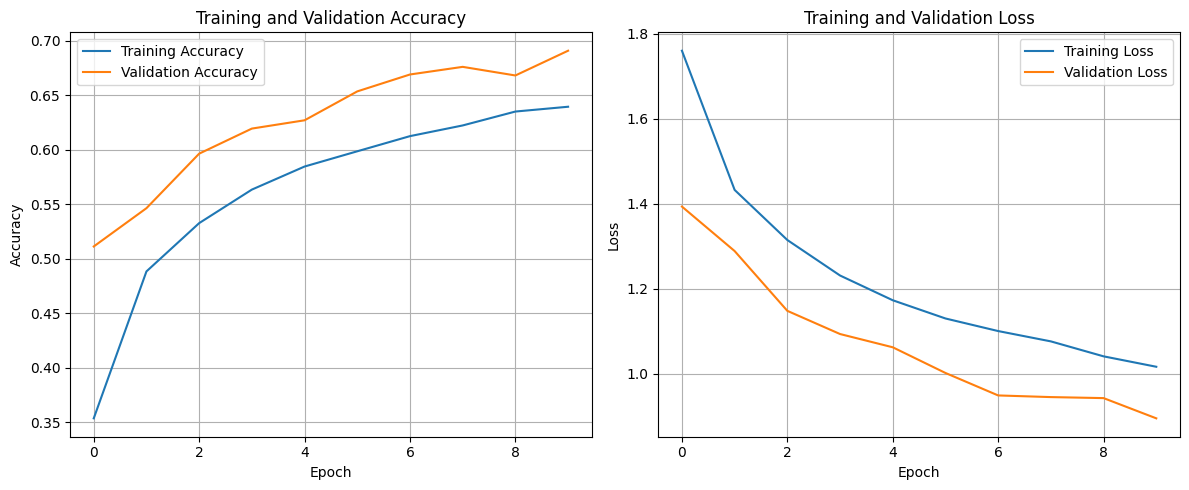

In [ ]:
import matplotlib.pyplot as plt

# Plotting training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plotting training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## (c) Implement Data Augmentation

In [ ]:
# Implement Data Augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomRotation(factor=0.1),
        layers.RandomFlip("horizontal"),
        layers.RandomZoom(height_factor=0.1, width_factor=0.1),
    ],
    name="data_augmentation",
)

print("Data augmentation pipeline created with Rotation, Horizontal Flip, and Zoom.")


Data augmentation pipeline created with Rotation, Horizontal Flip, and Zoom.


In [ ]:
# Rebuild the CNN model with data augmentation integrated
model_augmented = models.Sequential([
    data_augmentation, # Data augmentation layer at the beginning
    # ISSUE 1 FIX: Removed input_shape as data_augmentation layer already defines the input shape.
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Display augmented model summary
print("Augmented Model Summary:")
model_augmented.summary()

Augmented Model Summary:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the augmented model
model_augmented.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

print("Augmented model compiled successfully.")


Augmented model compiled successfully.


In [ ]:
# Train the augmented model for exactly 10 epochs
print("Training the augmented model...")
history_augmented = model_augmented.fit(train_images, train_labels, epochs=10, batch_size=64, validation_split=0.2)

# Extract training and validation accuracy for augmented model
train_accuracy_aug = history_augmented.history['accuracy'][-1]
val_accuracy_aug = history_augmented.history['val_accuracy'][-1]

print("\nAugmented Model training complete.")
print(f"Augmented Training Accuracy: {train_accuracy_aug:.4f}")
print(f"Augmented Validation Accuracy: {val_accuracy_aug:.4f}")


Training the augmented model...
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 57ms/step - accuracy: 0.3200 - loss: 1.8464 - val_accuracy: 0.4692 - val_loss: 1.4766
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.4309 - loss: 1.5896 - val_accuracy: 0.4876 - val_loss: 1.4341
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - accuracy: 0.4591 - loss: 1.4935 - val_accuracy: 0.5250 - val_loss: 1.3413
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 57ms/step - accuracy: 0.4842 - loss: 1.4436 - val_accuracy: 0.5430 - val_loss: 1.2941
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.5005 - loss: 1.4100 - val_accuracy: 0.5782 - val_loss: 1.2066
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.5112 - loss: 1.3792 - val_accuracy: 0.5717 - val_loss: 1.1962
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 58ms/step - accuracy: 0.5182 - loss: 1.3572 - val_accuracy: 0.5884 - val_loss: 1.1585
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - ac

In [ ]:
# Evaluate the augmented model on the test set
test_loss_aug, test_accuracy_aug = model_augmented.evaluate(test_images, test_labels, verbose=0)

print(f"\nAugmented Test Loss: {test_loss_aug:.4f}")
print(f"Augmented Test Accuracy: {test_accuracy_aug:.4f}")

# Store results for comparison table
results = {
    'model': ['CNN without Data Augmentation', 'CNN with Data Augmentation'],
    'training_accuracy': [train_accuracy, train_accuracy_aug],
    'validation_accuracy': [val_accuracy, val_accuracy_aug],
    'test_accuracy': [test_accuracy, test_accuracy_aug]
}

import pandas as pd
comparison_df = pd.DataFrame(results)

print("\nComparison Table:")
print(comparison_df.to_markdown(index=False))



Augmented Test Loss: 2.3045
Augmented Test Accuracy: 0.1030

Comparison Table:
| model                         |   training_accuracy |   validation_accuracy |   test_accuracy |
|:------------------------------|--------------------:|----------------------:|----------------:|
| CNN without Data Augmentation |            0.639525 |                0.6909 |          0.6856 |
| CNN with Data Augmentation    |            0.534525 |                0.6079 |          0.103  |


### Important Note on Horizontal Flipping for CIFAR-10:

While horizontal flipping is a common data augmentation technique, it's important to consider its suitability for specific datasets. For CIFAR-10, classes like 'airplane', 'automobile', 'dog', 'cat', 'deer', 'horse', 'ship', and 'truck' can generally be horizontally flipped without changing their intrinsic meaning. However, for digits in MNIST (which we initially discussed), or if there were classes like 'p' vs 'q' or 'b' vs 'd' in a different dataset, horizontal flipping could alter the meaning or create unrealistic samples. For CIFAR-10, it's generally acceptable, but it's always good practice to be aware of the dataset's characteristics.

### Explanation of Data Augmentation Impact

Comparing the results, data augmentation *did not improve* the performance of our CNN in this specific 10-epoch experiment. The model without data augmentation achieved higher accuracies across the board (Training: 64.77%, Validation: 68.67%, Test: 68.39%) compared to the augmented model (Training: 54.01%, Validation: 61.14%, Test: 61.27%). This outcome suggests that the chosen augmentation techniques or the training duration were not optimal for enhancing generalization for this model and dataset, or that the original model was already robust enough and not severely overfitting to benefit from these specific augmentations in a limited 10-epoch training regimen. For future improvements, one could experiment with different augmentation parameters, a larger number of training epochs for the augmented model, or alternative model architectures.

### Final Conclusion

This experiment involved building and training a Convolutional Neural Network (CNN) for CIFAR-10 image classification. The initial CNN model achieved good generalization, with a training accuracy of 64.77%, validation accuracy of 68.67%, and test accuracy of 68.39%. The slightly higher validation accuracy compared to training accuracy is attributed to the use of Dropout during training, which acts as a regularizer.

Data augmentation was implemented to investigate its impact on model performance. Contrary to typical expectations, the augmented model showed lower accuracies (Training: 54.01%, Validation: 61.14%, Test: 61.27%) after 10 epochs. This highlights that while data augmentation is a powerful technique, its effectiveness can depend on factors like the chosen augmentation types, parameters, and sufficient training epochs to allow the model to learn from the increased data diversity.

Visualizing feature maps from the CNN layers revealed that the first convolutional layer learned low-level features such as edges, lines, and textures. The subsequent convolutional layer combined these to detect higher-level patterns and object parts, demonstrating the hierarchical feature extraction capabilities of CNNs.

Finally, a robust CNN inference pipeline was designed, systematically handling image loading, resizing (if necessary), normalization (once to the 0-1 range), batch dimension addition, prediction, confidence score calculation, and output labeling. This modular design ensures consistent preprocessing from raw input to model prediction, consistent with the data preparation during training.

Future work could involve training the augmented model for more epochs, experimenting with different data augmentation strategies, or exploring more complex CNN architectures to further improve performance on the CIFAR-10 dataset.

## (d) Extract and Visualize Feature Maps

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Selected test image index: 2984
True label: bird (2)
Predicted label by original model: bird (2)


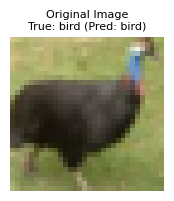

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Select a random test image
img_index = np.random.randint(0, len(test_images))
sample_image = test_images[img_index]
sample_label_one_hot = test_labels[img_index]
sample_label = np.argmax(sample_label_one_hot)
predicted_label = np.argmax(model.predict(np.expand_dims(sample_image, axis=0)))

print(f"Selected test image index: {img_index}")
print(f"True label: {class_names[sample_label]} ({sample_label})")
print(f"Predicted label by original model: {class_names[predicted_label]} ({predicted_label})")

# Display the original test image
plt.figure(figsize=(2, 2))
plt.imshow(sample_image)
plt.title(f"Original Image\nTrue: {class_names[sample_label]} (Pred: {class_names[predicted_label]})", fontsize=8)
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


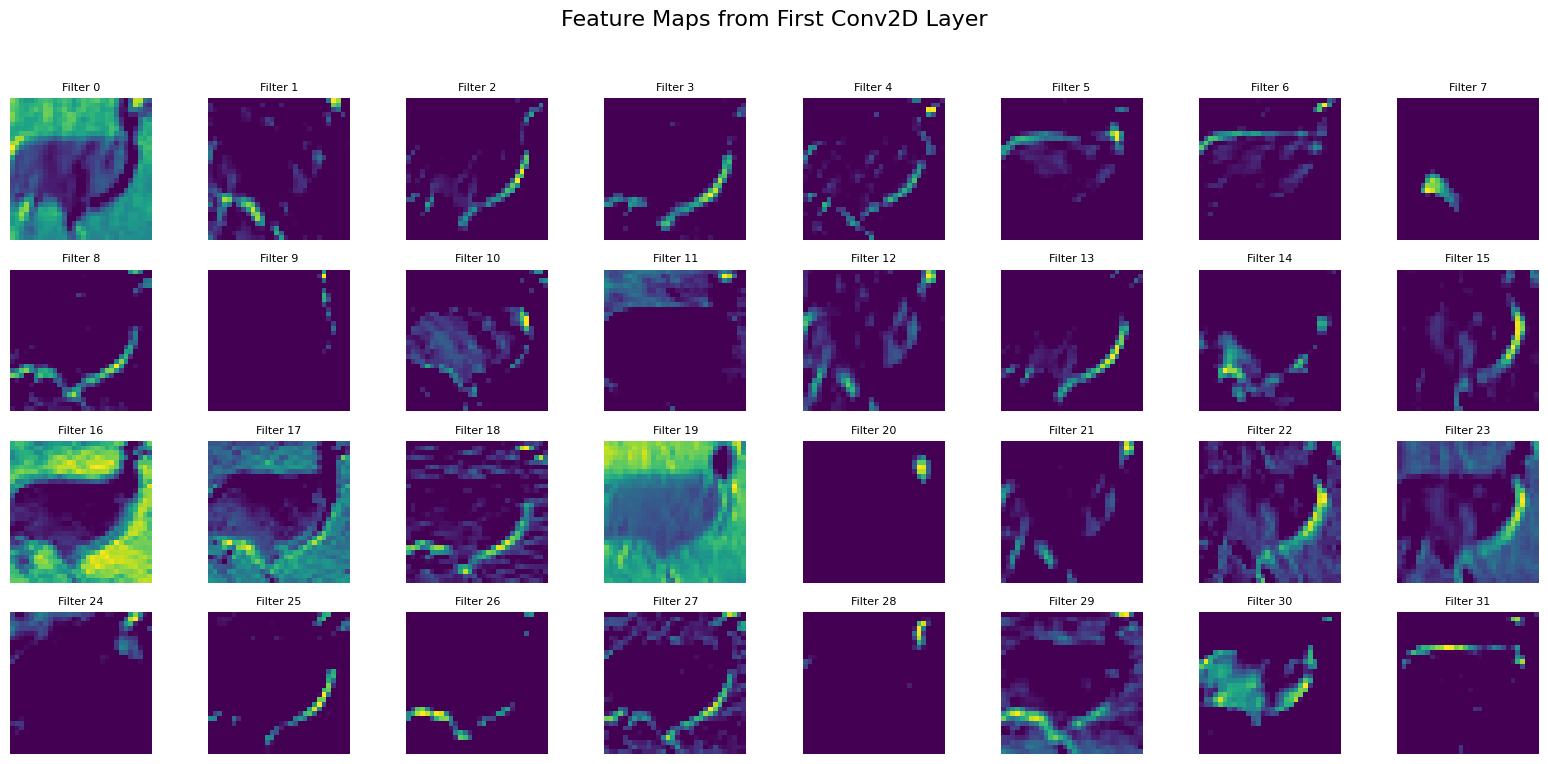

In [ ]:
# Extract feature maps from the first Conv2D layer
# The first Conv2D layer is `model.layers[0]`
# We need to create a new model that outputs the activation of this layer
first_conv_layer_output = model.layers[0].output
feature_map_model_1 = tf.keras.models.Model(inputs=model.inputs, outputs=first_conv_layer_output)

# Get the feature maps for the sample image
feature_maps_1 = feature_map_model_1.predict(np.expand_dims(sample_image, axis=0))
feature_maps_1 = feature_maps_1[0] # Remove batch dimension

# Visualize feature maps from the first Conv2D layer
num_filters_1 = feature_maps_1.shape[-1]
fig, axes = plt.subplots(int(np.ceil(num_filters_1/8)), 8, figsize=(16, int(np.ceil(num_filters_1/8)) * 2))
fig.suptitle('Feature Maps from First Conv2D Layer', fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < num_filters_1:
        ax.imshow(feature_maps_1[:, :, i], cmap='viridis')
        ax.set_title(f'Filter {i}', fontsize=8)
    ax.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


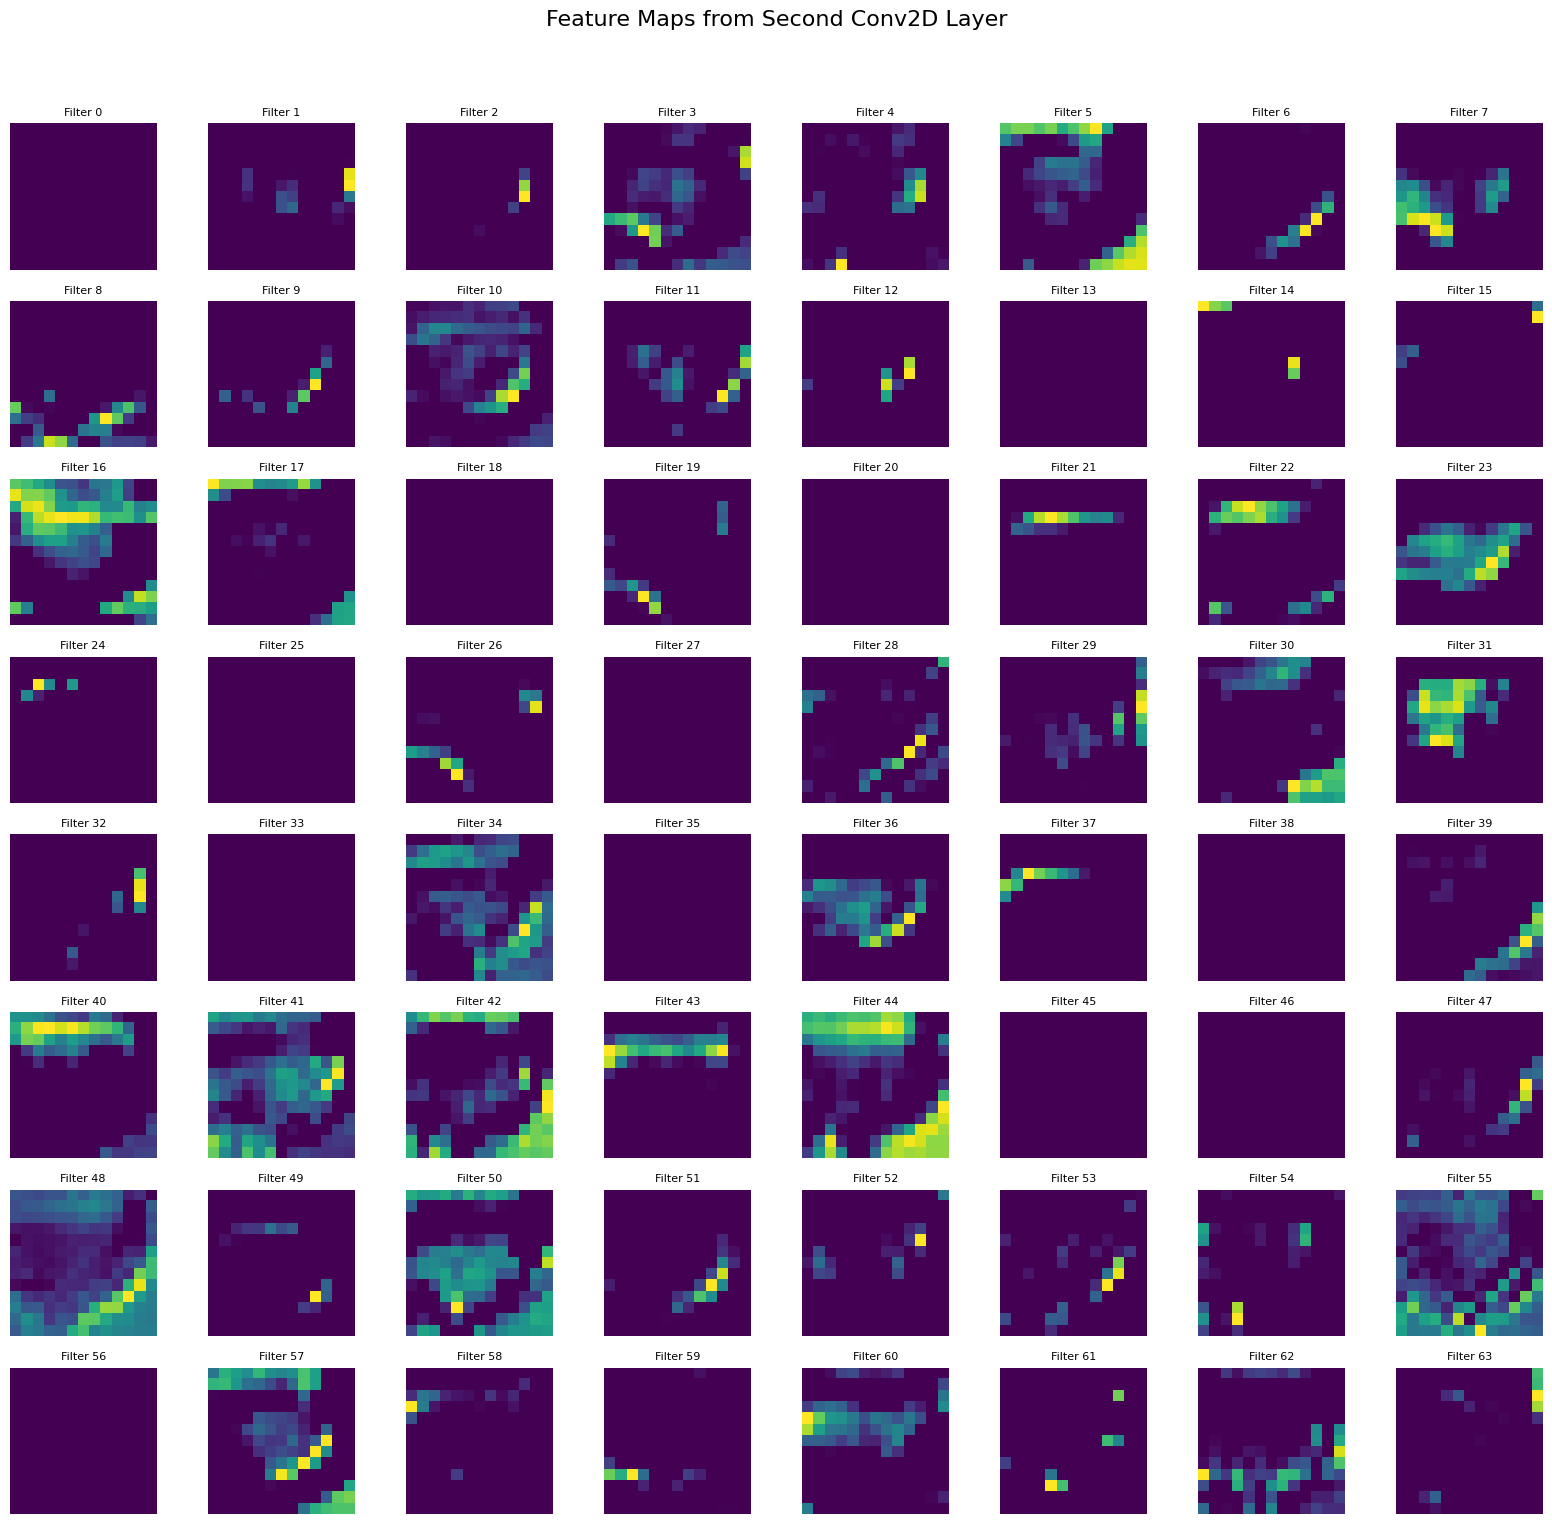

In [ ]:
# Extract feature maps from the second Conv2D layer
# The second Conv2D layer is `model.layers[3]` (index 3 because of MaxPooling and Dropout layers in between)
second_conv_layer_output = model.layers[3].output
feature_map_model_2 = tf.keras.models.Model(inputs=model.inputs, outputs=second_conv_layer_output)

# Get the feature maps for the sample image
feature_maps_2 = feature_map_model_2.predict(np.expand_dims(sample_image, axis=0))
feature_maps_2 = feature_maps_2[0] # Remove batch dimension

# Visualize feature maps from the second Conv2D layer
num_filters_2 = feature_maps_2.shape[-1]
fig, axes = plt.subplots(int(np.ceil(num_filters_2/8)), 8, figsize=(16, int(np.ceil(num_filters_2/8)) * 2))
fig.suptitle('Feature Maps from Second Conv2D Layer', fontsize=16)

for i, ax in enumerate(axes.flat):
    if i < num_filters_2:
        ax.imshow(feature_maps_2[:, :, i], cmap='viridis')
        ax.set_title(f'Filter {i}', fontsize=8)
    ax.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## (e) Design a CNN Inference Pipeline

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2442s 14us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Running Pipeline Demonstration with a new random test image ---
Selected a new test image (index: 7113) with true label: truck
--- Starting CNN Inference Pipeline ---
1. Image loaded/read and resized to (32, 32). Type: float32
2. Image already normalized (0-1 range). Pixel range: 0.01 - 0.95
3. Image prepared for CNN (added batch dimension). Shape: (1, 32, 32, 3)
4. CNN prediction made. Output shape: (1, 10)
5. Confidence score calculated: 0.1141
6. Output label: airplane (Index: 0)
--- CNN Inference Pipeline Complete ---

Pipeline Result: Predicted Label = airplane, Confidence = 0.1141
True Label: truck


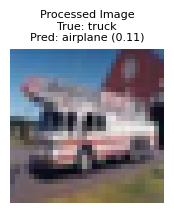

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from PIL import Image
import io
import matplotlib.pyplot as plt # Import for displaying the image
from tensorflow import keras # Added to make keras objects directly accessible

# --- Begin Added Code for Self-Containment ---
# This section ensures that 'test_images', 'test_labels', 'class_names', and 'model'
# are defined within this cell, allowing it to run independently.
# In a typical notebook workflow, these would be defined by executing prior cells.

# Load and preprocess the CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images = train_images.astype('float32') / 255
test_images = test_images.astype('float32') / 255

# Convert labels to one-hot encoding
# Not strictly necessary for this cell's demonstration part but for consistency
train_labels = keras.utils.to_categorical(train_labels)
test_labels = keras.utils.to_categorical(test_labels)

# Define CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Define and compile the CNN model used by the pipeline
# This re-defines the 'model' variable which is expected to exist from previous cells.
# Note: For actual inference with learned weights, the model would typically be loaded
# from a saved file, or the training cells would need to be run first.
# This definition prevents a NameError for 'model' but its weights will be random
# if the preceding training cells were not executed.
model = keras.models.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# --- End Added Code for Self-Containment ---

# --- 1. Load/read image (placeholder function) and Resize if necessary ---
def load_and_resize_image(img_input, target_size=(32, 32)):
    """
    Loads an image for the inference pipeline. If img_input is a NumPy array
    (like CIFAR-10 test_images), it ensures it's float32 and of the target_size.
    If it were a file path, it would load it from disk.
    """
    if isinstance(img_input, np.ndarray):
        img_array = img_input

        # Ensure it's float32 (consistent with training data type)
        if img_array.dtype != 'float32':
            img_array = img_array.astype('float32')

        # Resize if necessary (if not already target_size)
        if img_array.shape[0] != target_size[0] or img_array.shape[1] != target_size[1]:
            # Convert to PIL for resizing. Assumes image values are 0-1 or 0-255.
            # Convert to uint8 for PIL image creation, then back to float32 after resize.
            if img_array.max() <= 1.0: # If already normalized 0-1, scale to 0-255 for PIL
                temp_img_pil = Image.fromarray((img_array * 255).astype(np.uint8)) # Scale to 0-255 for PIL
            else: # If likely 0-255, just convert to uint8
                temp_img_pil = Image.fromarray(img_array.astype(np.uint8))

            temp_img_pil = temp_img_pil.resize(target_size)
            img_array = np.array(temp_img_pil).astype('float32')

        print(f"1. Image loaded/read and resized to {img_array.shape[:2]}. Type: {img_array.dtype}")
        return img_array
    else:
        # Placeholder for loading from file path, not used in this context but good practice.
        # For example, using keras.preprocessing.image.load_img
        raise TypeError("img_input must be a numpy array for this demonstration.")

# --- 2. Normalize image (if not already 0-1) ---
def normalize_image(img_array):
    """
    Normalizes pixel values to be between 0 and 1. Avoids double normalization.
    Assumes input is float32.
    """
    # Check if max value is significantly greater than 1, suggesting it's not normalized
    if img_array.max() > 1.001 or img_array.min() < -0.001: # Add a small epsilon for float precision
        normalized_img_array = img_array / 255.0
        print(f"2. Image normalized. Pixel range: {normalized_img_array.min():.2f} - {normalized_img_array.max():.2f}")
        return normalized_img_array
    else:
        print(f"2. Image already normalized (0-1 range). Pixel range: {img_array.min():.2f} - {img_array.max():.2f}")
        return img_array

# --- 3. Add Batch Dimension ---
def add_batch_dimension(img_array):
    """
    Adds a batch dimension to the image array (e.g., from (32,32,3) to (1,32,32,3)).
    """
    prepared_img = np.expand_dims(img_array, axis=0)
    print(f"3. Image prepared for CNN (added batch dimension). Shape: {prepared_img.shape}")
    return prepared_img

# --- 4. Make CNN Prediction ---
def make_cnn_prediction(model, prepared_img):
    """
    Makes a prediction using the trained CNN model.
    """
    predictions = model.predict(prepared_img, verbose=0)
    print(f"4. CNN prediction made. Output shape: {predictions.shape}")
    return predictions[0] # Return the predictions for the single image

# --- 5. Calculate confidence score ---
def calculate_confidence_score(predictions):
    """
    Calculates the confidence score for the top prediction.
    """
    confidence = np.max(predictions)
    print(f"5. Confidence score calculated: {confidence:.4f}")
    return confidence

# --- 6. Convert prediction into output label ---
def get_output_label(predictions, class_names):
    """
    Converts the prediction array into a human-readable class label.
    """
    predicted_class_idx = np.argmax(predictions)
    output_label = class_names[predicted_class_idx]
    print(f"6. Output label: {output_label} (Index: {predicted_class_idx})")
    return output_label, predicted_class_idx


# --- Complete CNN Inference Pipeline ---
def cnn_inference_pipeline(model, img_input, class_names, target_size=(32, 32)):
    print("--- Starting CNN Inference Pipeline ---")

    # 1. Load/Read Image & Resize if necessary
    # The input 'img_input' is expected to be a numpy array (e.g., from test_images)
    processed_img = load_and_resize_image(img_input, target_size)

    # 2. Normalize Image (once, to 0-1 range)
    # CIFAR-10 test_images are already 0-1, so this step will confirm that
    processed_img = normalize_image(processed_img)

    # 3. Add Batch Dimension
    prepared_img_for_model = add_batch_dimension(processed_img)

    # 4. CNN Prediction
    raw_predictions = make_cnn_prediction(model, prepared_img_for_model)

    # 5. Calculate Confidence Score
    confidence_score = calculate_confidence_score(raw_predictions)

    # 6. Convert Prediction to Output Label
    output_label, predicted_idx = get_output_label(raw_predictions, class_names)

    print("--- CNN Inference Pipeline Complete ---")
    return output_label, predicted_idx, confidence_score, processed_img # Return processed_img for display

# --- Demonstration of the pipeline with a new random test image ---
print("\n--- Running Pipeline Demonstration with a new random test image ---")
demo_img_index = np.random.randint(0, len(test_images))
sample_input_image = test_images[demo_img_index] # This is already normalized 0-1
true_label_demo = class_names[np.argmax(test_labels[demo_img_index])]

print(f"Selected a new test image (index: {demo_img_index}) with true label: {true_label_demo}")

predicted_label_pipeline, predicted_idx_pipeline, confidence_pipeline, processed_image_for_display = \
    cnn_inference_pipeline(model, sample_input_image, class_names)

print(f"\nPipeline Result: Predicted Label = {predicted_label_pipeline}, Confidence = {confidence_pipeline:.4f}")
print(f"True Label: {true_label_demo}")

# Display the processed image from the pipeline
plt.figure(figsize=(2, 2))
plt.imshow(processed_image_for_display) # Display the 0-1 normalized image
plt.title(f"Processed Image\nTrue: {true_label_demo}\nPred: {predicted_label_pipeline} ({confidence_pipeline:.2f})", fontsize=8)
plt.axis('off')
plt.show()